# RASMapper Spatial Review


In [1]:
from pathlib import Path
import json
import re
import time

import pandas as pd
from IPython.display import Image, Markdown, display

from ras_commander import RasExamples, RasMap
import ras_commander

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

# RASMapper screenshots require Windows + a local HEC-RAS/RASMapper install.
# Leave this True for the full visual demonstration. Set False for headless runs.
CAPTURE_SNAPSHOTS = True
RAS_VERSION = "6.6"
SNAPSHOT_TIMEOUT_SECONDS = 1800  # 30 minutes for large projects that open slowly.
SNAPSHOT_DELAY_SECONDS = 8
RUN_LOW_LEVEL_CAPTURE = False  # Optional extra demo of open/capture/close primitives.

RUN_ROOT = Path.cwd() / "working" / "notebook_runs" / "122_rasmapper_spatial_review"
PROJECT_NAMES = [
    "Balde Eagle Creek",
    "Muncie",
    "BaldEagleCrkMulti2D",
    "Davis",
    "NewOrleansMetro",
]

print(f"ras-commander: {ras_commander.__version__}")
print(f"Run folder: {RUN_ROOT}")
print(f"Capture snapshots: {CAPTURE_SNAPSHOTS}")

ras-commander: 0.94.0
Run folder: C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review
Capture snapshots: True


## Developer Mode

The committed notebook imports `ras_commander` normally. For local source development, install the repository in editable mode before running:

```powershell
uv pip install -e .
```

Generated example projects, screenshots, and review bundles are written under `working/notebook_runs/` or each extracted project's `RASMapper Screenshots` folder, not under `examples/`.

# RASMapper Spatial Review and Screenshot Workflows

This notebook demonstrates the `RasMap` APIs for controlling RASMapper state, launching standalone `RasMapper.exe`, capturing screenshots, and building repeatable spatial QA/QC evidence bundles.

The examples intentionally use several real `RasExamples` projects:

- **Balde Eagle Creek**: 1D cross-section and structure layers.
- **Muncie**: terrain, land-cover/map layers, 2D flow areas, and structures.
- **BaldEagleCrkMulti2D**: multiple geometries with differing 2D elements, breaklines, and SA/2D connections.
- **Davis**: urban storm system with pipes, pumps, storage, and 2D areas.
- **NewOrleansMetro**: large 2D surface model with pipes, pumps, breaklines, and SA/2D structures.

`RasMap.create_spatial_review_package()` writes to a project subfolder named **RASMapper Screenshots** by default. The notebook displays generated PNGs inline after each capture.

## API Coverage

This notebook touches the main RASMapper automation surface:

- Layer discovery: `parse_rasmap`, `list_map_layers`, `list_reference_map_layers`, `list_basemap_layers`, `list_standard_basemap_layers`, `list_terrain_layers`, `list_landcover_layers`, `list_soils_layers`, `list_infiltration_layers`, `list_geometry_layers`, `list_result_layers`, `list_geometry_features`.
- Layer mutation: `add_reference_map_layer`, `add_basemap_layer`, `set_map_layer_visibility`, `set_terrain_layer_visibility`, `set_geometry_layer_visibility`, `set_result_layer_visibility`, `set_update_legend_with_view`.
- View and bounds: `get_current_view`, `set_current_view`, `get_geometry_layer_bounds`, `get_geometry_feature_bounds`, `zoom_to_geometry_layer`.
- Window/screenshot workflows: `open_rasmapper`, `capture_rasmapper_snapshot`, `close_rasmapper`, and the higher-level `create_spatial_review_package`.

In [2]:
RUN_ROOT.mkdir(parents=True, exist_ok=True)

extracted = RasExamples.extract_project(
    PROJECT_NAMES,
    output_path=RUN_ROOT,
    suffix="rasmapper_demo",
)
projects = dict(zip(PROJECT_NAMES, extracted))

project_table = pd.DataFrame(
    [
        {
            "example_name": name,
            "project_path": str(path),
            "rasmap_files": ", ".join(p.name for p in sorted(Path(path).glob("*.rasmap"))),
        }
        for name, path in projects.items()
    ]
)
display(project_table)

2026-04-29 09:00:01 - ras_commander.RasExamples - INFO - Found zip file: C:\Users\billk_clb\AppData\Local\ras-commander\examples\Example_Projects_6_6.zip


2026-04-29 09:00:01 - ras_commander.RasExamples - INFO - Loading project data from CSV...


2026-04-29 09:00:01 - ras_commander.RasExamples - INFO - Loaded 68 projects from CSV.


2026-04-29 09:00:01 - ras_commander.RasExamples - INFO - ----- RasExamples Extracting Project -----


2026-04-29 09:00:01 - ras_commander.RasExamples - INFO - Extracting project 'Balde Eagle Creek' as 'Balde Eagle Creek_rasmapper_demo'


...

2026-04-29 09:00:03 - ras_commander.RasExamples - INFO - Downloading special project from: https://www.hec.usace.army.mil/confluence/rasdocs/hgt/files/latest/299502039/299502111/1/1747692522764/NewOrleansMetroPipesExample.zip


2026-04-29 09:00:03 - ras_commander.RasExamples - INFO - This may take a few moments...


2026-04-29 09:00:10 - ras_commander.RasExamples - INFO - Downloaded special project zip file to C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\NewOrleansMetro_rasmapper_demo_temp.zip


2026-04-29 09:00:11 - ras_commander.RasExamples - INFO - Successfully extracted special project 'NewOrleansMetro' to C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\NewOrleansMetro_rasmapper_demo


,example_name,project_path,rasmap_files
0,Balde Eagle Creek,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Balde Eagle Creek_rasmapper_demo,BaldEagle.rasmap
1,Muncie,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Muncie_rasmapper_demo,Muncie.rasmap
2,BaldEagleCrkMulti2D,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_rasmapper_demo,BaldEagleDamBrk.rasmap
3,Davis,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Davis_rasmapper_demo,DavisStormSystem.rasmap
4,NewOrleansMetro,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\NewOrleansMetro_rasmapper_demo,NewOrleansMetro.rasmap


In [3]:
def slugify(value: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", value).strip("_")


def compact_display(df: pd.DataFrame, columns=None, max_rows: int = 12):
    if df is None or df.empty:
        display(pd.DataFrame())
        return
    view = df.copy()
    if columns is not None:
        view = view[[c for c in columns if c in view.columns]]
    display(view.head(max_rows))


def first_terrain_name(project_path: Path, preferred: str | None = None) -> str | None:
    terrains = RasMap.list_terrain_layers(project_path)
    if terrains.empty:
        return None
    if preferred and preferred in set(terrains["name"]):
        return preferred
    checked = terrains.loc[terrains["checked"].fillna(False)]
    if not checked.empty:
        return checked.iloc[0]["name"]
    return terrains.iloc[0]["name"]


def maybe_map_category(project_path: Path, preferred):
    layers = RasMap.list_map_layers(project_path)
    if layers.empty:
        return None
    categories = set(layers["category"].dropna())
    preferred_values = [preferred] if isinstance(preferred, str) else list(preferred or [])
    selected = [value for value in preferred_values if value in categories]
    return selected or None


def display_snapshot(state: dict):
    snapshot = state.get("snapshot", {})
    path = snapshot.get("path")
    if path and snapshot.get("created"):
        display(Markdown(f"**Screenshot:** `{path}`"))
        display(Image(filename=path))
    else:
        display(Markdown(
            "No screenshot was created. "
            f"Requested: `{snapshot.get('requested')}`; error: `{snapshot.get('error')}`"
        ))


def create_demo_review(
    project_name: str,
    *,
    title: str,
    geometry_number: str,
    layer_type,
    terrain_name: str | None = None,
    feature_index: int | None = None,
    map_layer_category=None,
    include_results: bool = False,
    include_map_layers: bool = False,
) -> dict:
    project_path = Path(projects[project_name])
    snapshot_filename = f"{slugify(title)}.png"
    state = RasMap.create_spatial_review_package(
        project_path,
        geometry_number=geometry_number,
        layer_type=layer_type,
        feature_index=feature_index,
        terrain_name=terrain_name,
        map_layer_category=map_layer_category,
        include_results=include_results,
        include_map_layers=include_map_layers,
        capture_snapshot=CAPTURE_SNAPSHOTS,
        snapshot_filename=snapshot_filename,
        delay_seconds=SNAPSHOT_DELAY_SECONDS,
        snapshot_timeout_seconds=SNAPSHOT_TIMEOUT_SECONDS,
        ras_version=RAS_VERSION,
        require_snapshot=False,
    )
    assert Path(state["output_dir"]).name == "RASMapper Screenshots"
    display(Markdown(f"### {title}"))
    display(Markdown(f"Project: `{project_path}`"))
    display(Markdown(f"Review folder: `{state['output_dir']}`"))
    display(pd.DataFrame(state["preflight"])[["code", "passed", "message"]])
    display_snapshot(state)
    return state

## Project Inventory

Start by reading the `.rasmap` files into DataFrames. This gives a model-by-model catalog of terrain, map layers, land-cover/infiltration/soils layers, geometry elements, result layers, and current view state.

In [4]:
inventory_rows = []
catalogs = {}

for name, project_path in projects.items():
    project_path = Path(project_path)
    rasmap_df = RasMap.parse_rasmap(project_path / next(project_path.glob("*.rasmap")).name)
    map_layers = RasMap.list_map_layers(project_path)
    terrain_layers = RasMap.list_terrain_layers(project_path)
    landcover_layers = RasMap.list_landcover_layers(project_path)
    soils_layers = RasMap.list_soils_layers(project_path)
    infiltration_layers = RasMap.list_infiltration_layers(project_path)
    geometry_layers = RasMap.list_geometry_layers(project_path)
    result_layers = RasMap.list_result_layers(project_path)
    current_view = RasMap.get_current_view(project_path)

    catalogs[name] = {
        "rasmap_df": rasmap_df,
        "map_layers": map_layers,
        "terrain_layers": terrain_layers,
        "landcover_layers": landcover_layers,
        "soils_layers": soils_layers,
        "infiltration_layers": infiltration_layers,
        "geometry_layers": geometry_layers,
        "result_layers": result_layers,
        "current_view": current_view,
    }

    inventory_rows.append(
        {
            "project": name,
            "terrains": len(terrain_layers),
            "map_layers": len(map_layers),
            "reference_layers": int((map_layers.get("category", pd.Series(dtype=str)) == "reference").sum()) if not map_layers.empty else 0,
            "basemaps": int((map_layers.get("category", pd.Series(dtype=str)) == "basemap").sum()) if not map_layers.empty else 0,
            "landcover_layers": len(landcover_layers),
            "soils_layers": len(soils_layers),
            "infiltration_layers": len(infiltration_layers),
            "geometry_tree_rows": len(geometry_layers),
            "result_tree_rows": len(result_layers),
            "current_view_min_x": current_view.get("min_x"),
            "current_view_max_x": current_view.get("max_x"),
        }
    )

inventory = pd.DataFrame(inventory_rows)
display(inventory)

2026-04-29 09:00:11 - ras_commander.RasMap - INFO - Successfully parsed RASMapper file: C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Balde Eagle Creek_rasmapper_demo\BaldEagle.rasmap


2026-04-29 09:00:11 - ras_commander.RasMap - INFO - Found 0 map layers in .rasmap


2026-04-29 09:00:11 - ras_commander.RasMap - INFO - Successfully parsed RASMapper file: C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Muncie_rasmapper_demo\Muncie.rasmap


2026-04-29 09:00:11 - ras_commander.RasMap - INFO - Found 3 map layers in .rasmap


2026-04-29 09:00:11 - ras_commander.RasMap - INFO - Successfully parsed RASMapper file: C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_rasmapper_demo\BaldEagleDamBrk.rasmap


...

2026-04-29 09:00:11 - ras_commander.RasMap - INFO - Successfully parsed RASMapper file: C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Davis_rasmapper_demo\DavisStormSystem.rasmap


2026-04-29 09:00:11 - ras_commander.RasMap - INFO - Found 0 map layers in .rasmap


2026-04-29 09:00:11 - ras_commander.RasMap - INFO - Successfully parsed RASMapper file: C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\NewOrleansMetro_rasmapper_demo\NewOrleansMetro.rasmap


2026-04-29 09:00:11 - ras_commander.RasMap - INFO - Found 2 map layers in .rasmap


,project,terrains,map_layers,reference_layers,basemaps,landcover_layers,soils_layers,infiltration_layers,geometry_tree_rows,result_tree_rows,current_view_min_x,current_view_max_x
0,Balde Eagle Creek,0,0,0,0,0,0,0,27,0,1.967609e+06,2.065322e+06
1,Muncie,2,3,0,0,3,0,0,96,0,4.028388e+05,4.130636e+05
2,BaldEagleCrkMulti2D,1,4,0,1,1,1,1,305,0,1.944200e+06,2.139981e+06
3,Davis,1,0,0,0,0,0,0,39,47,6.625914e+06,6.646810e+06
4,NewOrleansMetro,1,2,0,1,1,0,0,40,49,3.658821e+06,3.685485e+06


In [5]:
for name in PROJECT_NAMES:
    display(Markdown(f"### {name}: geometry elements"))
    geometry_layers = catalogs[name]["geometry_layers"]
    compact_display(
        geometry_layers.loc[geometry_layers["category"].eq("geometry_element")],
        columns=["geometry_number", "geometry_name", "layer_name", "layer_type", "checked", "geometry_hdf_exists"],
        max_rows=20,
    )

### Balde Eagle Creek: geometry elements

,geometry_number,geometry_name,layer_name,layer_type,checked,geometry_hdf_exists
1,01,Existing Conditions - GIS Data,,RASXS,None,True
2,01,Existing Conditions - GIS Data,Culvert Groups,VirtualGeometryFeatureLayer,None,True
3,01,Existing Conditions - GIS Data,Culvert Barrels,VirtualGeometryFeatureLayer,None,True
4,01,Existing Conditions - GIS Data,Gate Groups,VirtualGeometryFeatureLayer,None,True
5,01,Existing Conditions - GIS Data,Gate Openings,VirtualGeometryFeatureLayer,None,True
6,01,Existing Conditions - GIS Data,Culvert Groups,VirtualGeometryFeatureLayer,None,True
7,01,Existing Conditions - GIS Data,Culvert Barrels,VirtualGeometryFeatureLayer,None,True
8,01,Existing Conditions - GIS Data,Rating Curve Outlets,VirtualGeometryFeatureLayer,None,True
9,01,Existing Conditions - GIS Data,Outlet Time Series,VirtualGeometryFeatureLayer,None,True
10,01,Existing Conditions - GIS Data,Gate Groups,VirtualGeometryFeatureLayer,None,True


### Muncie: geometry elements

,geometry_number,geometry_name,layer_name,layer_type,checked,geometry_hdf_exists
1,01,Muncie Base Geometry - 9 SAs,,RASRiver,True,True
2,01,Muncie Base Geometry - 9 SAs,,RASBankLines,True,True
3,01,Muncie Base Geometry - 9 SAs,,RASXS,True,True
4,01,Muncie Base Geometry - 9 SAs,,RASEdgeLines,True,True
5,01,Muncie Base Geometry - 9 SAs,,MeshPerimeterLayer,None,True
6,01,Muncie Base Geometry - 9 SAs,Culvert Groups,VirtualGeometryFeatureLayer,None,True
7,01,Muncie Base Geometry - 9 SAs,Culvert Barrels,VirtualGeometryFeatureLayer,None,True
8,01,Muncie Base Geometry - 9 SAs,Gate Groups,VirtualGeometryFeatureLayer,None,True
9,01,Muncie Base Geometry - 9 SAs,Gate Openings,VirtualGeometryFeatureLayer,None,True
10,01,Muncie Base Geometry - 9 SAs,Culvert Groups,VirtualGeometryFeatureLayer,None,True


### BaldEagleCrkMulti2D: geometry elements

,geometry_number,geometry_name,layer_name,layer_type,checked,geometry_hdf_exists
1,06,Bald Eagle Multi 2D Areas,,RASRiver,True,True
2,06,Bald Eagle Multi 2D Areas,,RASJunction,True,True
3,06,Bald Eagle Multi 2D Areas,XS,RASXS,True,True
4,06,Bald Eagle Multi 2D Areas,,RASStorageArea,True,True
5,06,Bald Eagle Multi 2D Areas,,RASD2FlowArea,True,True
6,06,Bald Eagle Multi 2D Areas,,MeshPerimeterLayer,None,True
7,06,Bald Eagle Multi 2D Areas,Culvert Groups,VirtualGeometryFeatureLayer,None,True
8,06,Bald Eagle Multi 2D Areas,Culvert Barrels,VirtualGeometryFeatureLayer,None,True
9,06,Bald Eagle Multi 2D Areas,Gate Groups,VirtualGeometryFeatureLayer,None,True
10,06,Bald Eagle Multi 2D Areas,Gate Openings,VirtualGeometryFeatureLayer,None,True


### Davis: geometry elements

,geometry_number,geometry_name,layer_name,layer_type,checked,geometry_hdf_exists
1,02,Davis Full System w_ Pump,,RASRiver,None,True
2,02,Davis Full System w_ Pump,,RASJunction,None,True
3,02,Davis Full System w_ Pump,,RASXS,None,True
4,02,Davis Full System w_ Pump,,RASStorageArea,None,True
5,02,Davis Full System w_ Pump,,RASD2FlowArea,True,True
6,02,Davis Full System w_ Pump,,MeshPerimeterLayer,True,True
7,02,Davis Full System w_ Pump,,MeshPointLayer,True,True
8,02,Davis Full System w_ Pump,Culvert Groups,VirtualGeometryFeatureLayer,None,True
9,02,Davis Full System w_ Pump,Culvert Barrels,VirtualGeometryFeatureLayer,None,True
10,02,Davis Full System w_ Pump,Gate Groups,VirtualGeometryFeatureLayer,None,True


### NewOrleansMetro: geometry elements

,geometry_number,geometry_name,layer_name,layer_type,checked,geometry_hdf_exists
1,02,2D Surface Model w Pipes,,RASRiver,None,True
2,02,2D Surface Model w Pipes,,RASJunction,None,True
3,02,2D Surface Model w Pipes,,RASXS,None,True
4,02,2D Surface Model w Pipes,,RASStorageArea,None,True
5,02,2D Surface Model w Pipes,,RASD2FlowArea,True,True
6,02,2D Surface Model w Pipes,,MeshPerimeterLayer,None,True
7,02,2D Surface Model w Pipes,,RASBreakLines,True,True
8,02,2D Surface Model w Pipes,Culvert Groups,VirtualGeometryFeatureLayer,None,True
9,02,2D Surface Model w Pipes,Culvert Barrels,VirtualGeometryFeatureLayer,None,True
10,02,2D Surface Model w Pipes,Gate Groups,VirtualGeometryFeatureLayer,None,True


## Map Layers: Add, List, Validate, and Toggle

The Muncie example is a convenient place to demonstrate map-layer management. The notebook creates a tiny WGS84 GeoJSON reference layer, rejects a projected GeoJSON, adds a standard basemap, and then uses layer-state controls to build figure context.

In [6]:
muncie = Path(projects["Muncie"])
gis_dir = muncie / "GIS_Data"
gis_dir.mkdir(exist_ok=True)

good_geojson = gis_dir / "rasmapper_demo_wgs84.geojson"
good_geojson.write_text(
    json.dumps(
        {
            "type": "FeatureCollection",
            "features": [
                {
                    "type": "Feature",
                    "properties": {"name": "RASMapper demo polygon"},
                    "geometry": {
                        "type": "Polygon",
                        "coordinates": [[
                            [-85.43, 40.18],
                            [-85.42, 40.18],
                            [-85.42, 40.19],
                            [-85.43, 40.19],
                            [-85.43, 40.18],
                        ]],
                    },
                }
            ],
        }
    ),
    encoding="utf-8",
)

bad_geojson = gis_dir / "rasmapper_demo_projected.geojson"
bad_geojson.write_text(
    json.dumps(
        {
            "type": "FeatureCollection",
            "crs": {"type": "name", "properties": {"name": "EPSG:3857"}},
            "features": [
                {
                    "type": "Feature",
                    "properties": {"name": "Projected demo polygon"},
                    "geometry": {
                        "type": "Polygon",
                        "coordinates": [[[1000000, 5000000], [1001000, 5000000], [1001000, 5001000], [1000000, 5001000], [1000000, 5000000]]],
                    },
                }
            ],
        }
    ),
    encoding="utf-8",
)

display(RasMap.list_standard_basemap_layers())

RasMap.add_reference_map_layer(muncie, good_geojson, layer_name="Demo WGS84 GeoJSON")
try:
    RasMap.add_reference_map_layer(muncie, bad_geojson, layer_name="Demo Projected GeoJSON")
except ValueError as exc:
    display(Markdown(f"Projected GeoJSON rejected as expected: `{exc}`"))

RasMap.add_basemap_layer(muncie, "USGS Topo", checked=True)

display(Markdown("### Muncie map layers after edits"))
compact_display(
    RasMap.list_map_layers(muncie),
    columns=["name", "type", "category", "checked", "filename", "resolved_path", "exists"],
    max_rows=30,
)

display(Markdown("### Reference layers"))
compact_display(RasMap.list_reference_map_layers(muncie), columns=["name", "type", "checked", "resolved_path", "exists"])

display(Markdown("### Basemap layers"))
compact_display(RasMap.list_basemap_layers(muncie), columns=["name", "type", "checked", "filename", "is_standard_basemap"])

,name,type,filename,resample_method
0,Google Hybrid,WMSLayer,%LocalAppData%\HEC\Mapping\5.1\XML\Google Hybrid.xml,near
1,Bing Satellite,WMSLayer,%LocalAppData%\HEC\Mapping\5.1\XML\Bing Satellite.xml,near
2,ArcGIS NatGeo World Map,WMSLayer,%LocalAppData%\HEC\Mapping\5.1\XML\ArcGIS NatGeo World Map.xml,near
3,ArcGIS USA Topo Maps,WMSLayer,%LocalAppData%\HEC\Mapping\5.1\XML\ArcGIS USA Topo Maps.xml,near
4,Google Terrain Streets Water,WMSLayer,%LocalAppData%\HEC\Mapping\5.1\XML\Google Terrain Streets Water.xml,near
5,OpenStreetMaps,WMSLayer,%LocalAppData%\HEC\Mapping\5.1\XML\OpenStreetMaps.xml,near
6,USGS Imagery,WMSLayer,%LocalAppData%\HEC\Mapping\5.1\XML\USGS Imagery.xml,near
7,USGS Topo,WMSLayer,%LocalAppData%\HEC\Mapping\5.1\XML\USGS Topo.xml,near


2026-04-29 09:00:11 - ras_commander._rasmap_layer_helper - INFO - Added reference map layer 'Demo WGS84 GeoJSON' to C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Muncie_rasmapper_demo\Muncie.rasmap


Projected GeoJSON rejected as expected: `GeoJSON source must be WGS84/EPSG:4326 for RASMapper: C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Muncie_rasmapper_demo\GIS_Data\rasmapper_demo_projected.geojson. Coordinate bounds look projected, not lon/lat: (1000000.0, 5000000.0, 1001000.0, 5001000.0)`

2026-04-29 09:00:11 - ras_commander._rasmap_layer_helper - INFO - Added basemap layer 'USGS Topo' to C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Muncie_rasmapper_demo\Muncie.rasmap


### Muncie map layers after edits

...

,name,type,category,checked,filename,resolved_path,exists
0,Land Cover,LandCoverLayer,land_classification,False,.\LandCover\LandCoverUserShapefile.hdf,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Muncie_rasmapper_demo\LandCover\LandCoverUser...,True
1,LandCoverUSGSGrid,LandCoverLayer,land_classification,False,.\LandCover\LandCoverUSGSGrid.hdf,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Muncie_rasmapper_demo\LandCover\LandCoverUSGS...,True
2,LandCoverCombined,LandCoverLayer,land_classification,False,.\LandCover\LandCoverCombined.hdf,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Muncie_rasmapper_demo\LandCover\LandCoverComb...,True
3,Demo WGS84 GeoJSON,PolygonFeatureLayer,reference,True,.\GIS_Data\rasmapper_demo_wgs84.geojson,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Muncie_rasmapper_demo\GIS_Data\rasmapper_demo...,True
4,USGS Topo,WMSLayer,basemap,True,%LocalAppData%\HEC\Mapping\5.1\XML\USGS Topo.xml,C:\Users\billk_clb\AppData\Local\HEC\Mapping\5.1\XML\USGS Topo.xml,True


### Reference layers

,name,type,checked,resolved_path,exists
3,Demo WGS84 GeoJSON,PolygonFeatureLayer,True,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Muncie_rasmapper_demo\GIS_Data\rasmapper_demo...,True


### Basemap layers

,name,type,checked,filename,is_standard_basemap
4,USGS Topo,WMSLayer,True,%LocalAppData%\HEC\Mapping\5.1\XML\USGS Topo.xml,True


In [7]:
# Visibility controls are useful before launching RASMapper for figures.
RasMap.set_map_layer_visibility(muncie, checked=False)
RasMap.set_map_layer_visibility(muncie, category=["land_classification", "reference"], checked=True, exclusive=True)
RasMap.set_terrain_layer_visibility(muncie, terrain_name=first_terrain_name(muncie, "TerrainWithChannel"), checked=True, exclusive=True)
RasMap.set_update_legend_with_view(muncie, include_map_layers=True)

display(Markdown("### Visible map layers after figure-state setup"))
visible_maps = RasMap.list_map_layers(muncie)
compact_display(
    visible_maps.loc[visible_maps["checked"].fillna(False)],
    columns=["name", "category", "type", "checked"],
    max_rows=30,
)

### Visible map layers after figure-state setup

2026-04-29 09:00:11 - ras_commander.RasMap - INFO - Found 5 map layers in .rasmap


,name,category,type,checked
0,Land Cover,land_classification,LandCoverLayer,True
1,LandCoverUSGSGrid,land_classification,LandCoverLayer,True
2,LandCoverCombined,land_classification,LandCoverLayer,True
3,Demo WGS84 GeoJSON,reference,PolygonFeatureLayer,True


In [8]:
# Give the 1D Bald Eagle Creek screenshot a standard basemap for visual context.
# The other examples already have useful terrain or map context, so leave them unchanged.
balde_eagle = Path(projects["Balde Eagle Creek"])
if RasMap.list_basemap_layers(balde_eagle).empty:
    RasMap.add_basemap_layer(balde_eagle, "USGS Topo", checked=False)

basemap_summary = []
for name, project_path in projects.items():
    basemaps = RasMap.list_basemap_layers(project_path)
    basemap_summary.append({"project": name, "basemap_count": len(basemaps), "basemap_names": basemaps["name"].tolist() if not basemaps.empty else []})

display(pd.DataFrame(basemap_summary))

2026-04-29 09:00:11 - ras_commander._rasmap_layer_helper - INFO - Added basemap layer 'USGS Topo' to C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Balde Eagle Creek_rasmapper_demo\BaldEagle.rasmap


,project,basemap_count,basemap_names
0,Balde Eagle Creek,1,[USGS Topo]
1,Muncie,1,[USGS Topo]
2,BaldEagleCrkMulti2D,1,[Google Hybrid]
3,Davis,0,[]
4,NewOrleansMetro,1,[Google Hybrid]


## Bounds and Feature Discovery

Geometry-layer screenshots are driven from compiled geometry HDF extents. Feature selectors do not hide individual features; they only center the view on one feature and zoom out for context.

In [9]:
multi2d = Path(projects["BaldEagleCrkMulti2D"])
multi_layers = RasMap.list_geometry_layers(multi2d)
multi_g03 = multi_layers.loc[
    (multi_layers["geometry_number"] == "03")
    & (multi_layers["category"] == "geometry_element")
]
display(multi_g03[["layer_id", "layer_name", "layer_type", "checked", "geometry_hdf_path"]])

g03_hdf = Path(multi_g03["geometry_hdf_path"].dropna().iloc[0])
for layer_type in ["RASD2FlowArea", "RASBreakLines", "SA2DStructureLayer", "RASXS"]:
    bounds = RasMap.get_geometry_layer_bounds(g03_hdf, layer_type=layer_type)
    display(Markdown(f"**{layer_type} bounds**"))
    display(pd.DataFrame([bounds]))
    features = RasMap.list_geometry_features(g03_hdf, layer_type=layer_type)
    compact_display(features, columns=["layer_type", "feature_index", "feature_name", "feature_type", "min_x", "min_y", "max_x", "max_y"], max_rows=8)

,layer_id,layer_name,layer_type,checked,geometry_hdf_path
244,geometry:8:layer:0:RASXS,,RASXS,None,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_rasmapper_demo\BaldEagleD...
245,geometry:8:layer:1:RASD2FlowArea,,RASD2FlowArea,True,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_rasmapper_demo\BaldEagleD...
246,geometry:8:layer:2:MeshPerimeterLayer,,MeshPerimeterLayer,None,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_rasmapper_demo\BaldEagleD...
247,geometry:8:layer:3:MeshPointLayer,,MeshPointLayer,True,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_rasmapper_demo\BaldEagleD...
248,geometry:8:layer:4:RASBreakLines,,RASBreakLines,True,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_rasmapper_demo\BaldEagleD...
249,geometry:8:layer:5:MeshRegionLayer,,MeshRegionLayer,True,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_rasmapper_demo\BaldEagleD...
250,geometry:8:layer:6:VirtualGeometryFeatureLayer:Culvert Groups,Culvert Groups,VirtualGeometryFeatureLayer,None,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_rasmapper_demo\BaldEagleD...
251,geometry:8:layer:7:VirtualGeometryFeatureLayer:Culvert Barrels,Culvert Barrels,VirtualGeometryFeatureLayer,None,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_rasmapper_demo\BaldEagleD...
252,geometry:8:layer:8:VirtualGeometryFeatureLayer:Gate Groups,Gate Groups,VirtualGeometryFeatureLayer,None,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_rasmapper_demo\BaldEagleD...
253,geometry:8:layer:9:VirtualGeometryFeatureLayer:Gate Openings,Gate Openings,VirtualGeometryFeatureLayer,None,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_rasmapper_demo\BaldEagleD...


**RASD2FlowArea bounds**

,geometry_hdf_path,layer_type,dataset_paths,min_x,min_y,max_x,max_y,width,height,point_count,has_bounds
0,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_rasmapper_demo\BaldEagleD...,RASD2FlowArea,"[Geometry/2D Flow Areas/Polygon Points, Geometry/2D Flow Areas/BaldEagleCr/Perimeter, Geometry/2D Flow Areas/BaldEag...",1.965982e+06,289578.114005,2.084790e+06,371007.582554,118808.363928,81429.468549,30993,True


,layer_type,feature_index,feature_name,feature_type,min_x,min_y,max_x,max_y
0,RASD2FlowArea,0,BaldEagleCr,,1.965982e+06,289578.114005,2.084790e+06,371007.582554


**RASBreakLines bounds**

...

,geometry_hdf_path,layer_type,dataset_paths,min_x,min_y,max_x,max_y,width,height,point_count,has_bounds
0,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_rasmapper_demo\BaldEagleD...,SA2DStructureLayer,[Geometry/Structures/Centerline Points],2002713.51,320226.29,2.063773e+06,356122.481,61059.509557,35896.191,366,True


,layer_type,feature_index,feature_name,feature_type,min_x,min_y,max_x,max_y
0,SA2DStructureLayer,0,Highway 120,Connection,2.055018e+06,349065.053429,2.055374e+06,349424.354113
1,SA2DStructureLayer,1,Highway 150,Connection,2.036935e+06,344676.056345,2.037221e+06,344713.620738
2,SA2DStructureLayer,2,Highway 150 Lowe,Connection,2.044745e+06,347580.050645,2.044792e+06,347866.742467
3,SA2DStructureLayer,3,Highway 220,Connection,2.062470e+06,351811.419878,2.063773e+06,351897.646783
4,SA2DStructureLayer,4,Hwy 220 Upper,Connection,2.052265e+06,347672.704501,2.052616e+06,348354.898113
5,SA2DStructureLayer,5,Lower Levee,Connection,2.047901e+06,351772.114764,2.060721e+06,356122.481000
6,SA2DStructureLayer,6,Middle Levee,Connection,2.052761e+06,348474.118034,2.061083e+06,351792.461700
7,SA2DStructureLayer,7,Mountain Rd,Connection,2.023387e+06,333142.559517,2.023735e+06,333168.678259


**RASXS bounds**

,geometry_hdf_path,layer_type,dataset_paths,min_x,min_y,max_x,max_y,width,height,point_count,has_bounds
0,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_rasmapper_demo\BaldEagleD...,RASXS,[],None,None,None,None,None,None,0,False


""


In [10]:
# View setters can be used directly when you already know the bounds.
original_view = RasMap.get_current_view(multi2d)
display(pd.DataFrame([original_view]))

zoomed = RasMap.zoom_to_geometry_layer(
    multi2d,
    geometry_number="03",
    layer_type="RASBreakLines",
    feature_index=0,
)
display(pd.DataFrame([zoomed["view"]]))

# Restore the original view before the screenshot examples below.
if original_view.get("has_current_view"):
    RasMap.set_current_view(
        multi2d,
        min_x=original_view["min_x"],
        min_y=original_view["min_y"],
        max_x=original_view["max_x"],
        max_y=original_view["max_y"],
    )

,rasmap_path,projection_path,min_x,max_x,min_y,max_y,width,height,has_current_view
0,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_rasmapper_demo\BaldEagleD...,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_rasmapper_demo\Terrain\Pr...,1.944200e+06,2.139981e+06,271582.974332,394630.889345,195780.690689,123047.915013,True


,rasmap_path,projection_path,min_x,max_x,min_y,max_y,width,height,has_current_view
0,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_rasmapper_demo\BaldEagleD...,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_rasmapper_demo\Terrain\Pr...,2000832.852,2010003.216,319125.08505,324624.49515,9170.364,5499.4101,True


## Screenshot Demonstrations

Each call below writes an audit package and optional PNG into the project's default **RASMapper Screenshots** folder, then displays the screenshot inline. The same code can run headlessly by setting `CAPTURE_SNAPSHOTS = False` in the first cell.

2026-04-29 09:00:12 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe via filesystem (x86)


2026-04-29 09:00:12 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 5\Ras.exe via filesystem (x86)


2026-04-29 09:00:12 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 4 at C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 4\Ras.exe via filesystem (x86)


2026-04-29 09:00:12 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.5 at C:\Program Files (x86)\HEC\HEC-RAS\6.5\Ras.exe via filesystem (x86)


2026-04-29 09:00:12 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.4.1 at C:\Program Files (x86)\HEC\HEC-RAS\6.4.1\Ras.exe via filesystem (x86)


...

### Bald Eagle Creek 1D Cross Sections

Project: `C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Balde Eagle Creek_rasmapper_demo`

Review folder: `C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Balde Eagle Creek_rasmapper_demo\RASMapper Screenshots`

,code,passed,message
0,rasmap_exists,True,RASMapper file exists: C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Balde Eagle Creek_rasm...
1,geometry_layers_found,True,Geometry layers were found in the .rasmap.
2,selected_geometry_layers_found,True,Selected geometry layer(s) were found.
3,selected_geometry_hdf_exists,True,Selected geometry layer HDF files exist.


**Screenshot:** `C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Balde Eagle Creek_rasmapper_demo\RASMapper Screenshots\Bald_Eagle_Creek_1D_Cross_Sections.png`

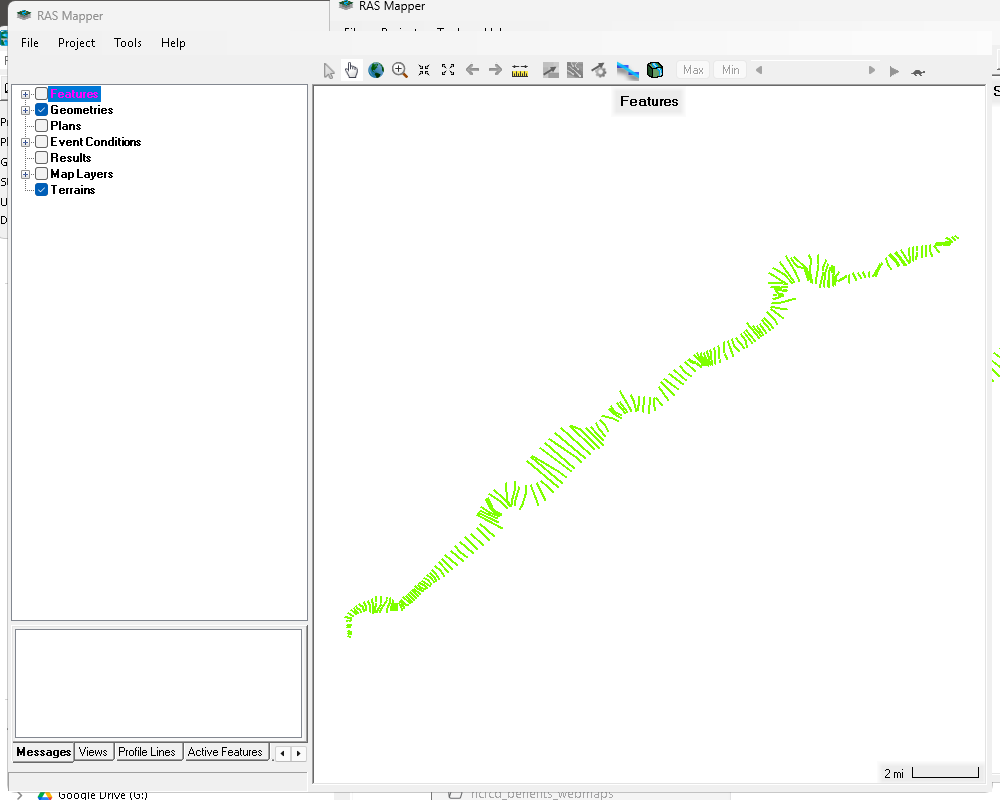

In [11]:
review_states = {}

review_states["Balde Eagle Creek 1D XS"] = create_demo_review(
    "Balde Eagle Creek",
    title="Bald Eagle Creek 1D Cross Sections",
    geometry_number="01",
    layer_type=["RASXS", "StructureLayer"],
    include_map_layers=False,
    include_results=False,
)

2026-04-29 09:00:20 - ras_commander.RasMap - INFO - Found 5 map layers in .rasmap


2026-04-29 09:00:20 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe via filesystem (x86)


2026-04-29 09:00:20 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 5\Ras.exe via filesystem (x86)


2026-04-29 09:00:20 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 4 at C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 4\Ras.exe via filesystem (x86)


2026-04-29 09:00:20 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.5 at C:\Program Files (x86)\HEC\HEC-RAS\6.5\Ras.exe via filesystem (x86)


...

### Muncie 2D Flow Area and Structures

Project: `C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Muncie_rasmapper_demo`

Review folder: `C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Muncie_rasmapper_demo\RASMapper Screenshots`

,code,passed,message
0,rasmap_exists,True,RASMapper file exists: C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Muncie_rasmapper_demo\...
1,geometry_layers_found,True,Geometry layers were found in the .rasmap.
2,selected_geometry_layers_found,True,Selected geometry layer(s) were found.
3,selected_geometry_hdf_exists,True,Selected geometry layer HDF files exist.
4,selected_geometry_features_found,True,Selected geometry feature(s) were found.
5,selected_map_layers_found,True,Selected map layer(s) were found.
6,selected_terrain_found,True,Selected terrain layer exists: TerrainWithChannel
7,geojson_wgs84,True,GeoJSON layer is WGS84-compatible: Demo WGS84 GeoJSON


**Screenshot:** `C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Muncie_rasmapper_demo\RASMapper Screenshots\Muncie_2D_Flow_Area_and_Structures.png`

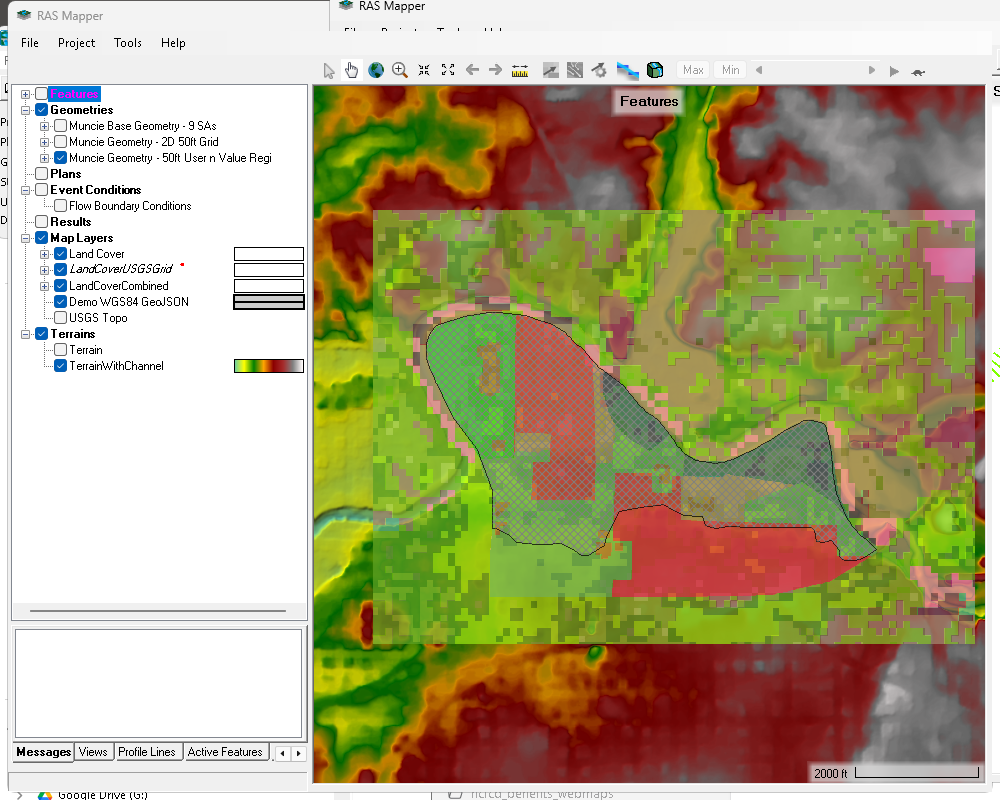

In [12]:
review_states["Muncie 2D structures"] = create_demo_review(
    "Muncie",
    title="Muncie 2D Flow Area and Structures",
    geometry_number="04",
    layer_type=["RASD2FlowArea", "StructureLayer"],
    terrain_name=first_terrain_name(Path(projects["Muncie"]), "TerrainWithChannel"),
    feature_index=0,
    map_layer_category=maybe_map_category(Path(projects["Muncie"]), ["land_classification", "reference"]),
)

2026-04-29 09:00:28 - ras_commander.RasMap - INFO - Found 4 map layers in .rasmap


2026-04-29 09:00:29 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe via filesystem (x86)


2026-04-29 09:00:29 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 5\Ras.exe via filesystem (x86)


2026-04-29 09:00:29 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 4 at C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 4\Ras.exe via filesystem (x86)


2026-04-29 09:00:29 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.5 at C:\Program Files (x86)\HEC\HEC-RAS\6.5\Ras.exe via filesystem (x86)


...

### Bald Eagle Multi2D Breaklines and SA2D Structures

Project: `C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_rasmapper_demo`

Review folder: `C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_rasmapper_demo\RASMapper Screenshots`

,code,passed,message
0,rasmap_exists,True,RASMapper file exists: C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_ra...
1,geometry_layers_found,True,Geometry layers were found in the .rasmap.
2,selected_geometry_layers_found,True,Selected geometry layer(s) were found.
3,selected_geometry_hdf_exists,True,Selected geometry layer HDF files exist.
4,selected_geometry_features_found,True,Selected geometry feature(s) were found.
5,selected_map_layers_found,True,Selected map layer(s) were found.
6,selected_terrain_found,True,Selected terrain layer exists: Terrain50


**Screenshot:** `C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_rasmapper_demo\RASMapper Screenshots\Bald_Eagle_Multi2D_Breaklines_and_SA2D_Structures.png`

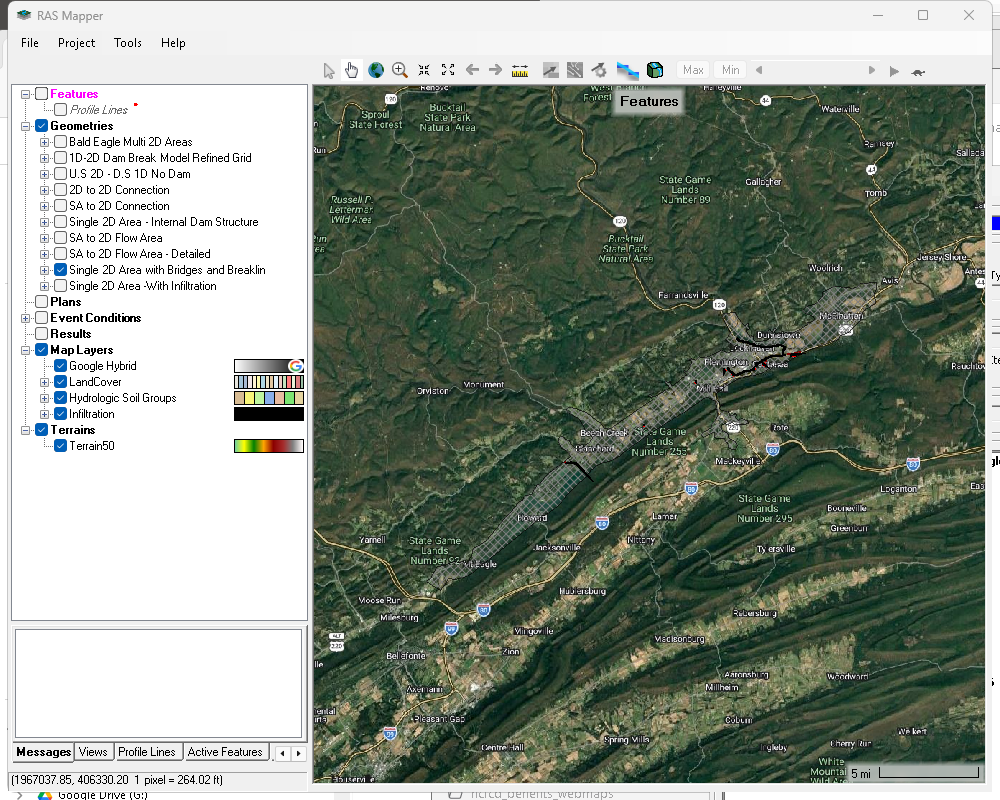

In [13]:
review_states["BaldEagleCrkMulti2D breaklines"] = create_demo_review(
    "BaldEagleCrkMulti2D",
    title="Bald Eagle Multi2D Breaklines and SA2D Structures",
    geometry_number="03",
    layer_type=["RASD2FlowArea", "RASBreakLines", "SA2DStructureLayer", "MeshRegionLayer"],
    terrain_name=first_terrain_name(Path(projects["BaldEagleCrkMulti2D"])),
    feature_index=0,
    map_layer_category=maybe_map_category(Path(projects["BaldEagleCrkMulti2D"]), ["land_classification", "basemap"]),
)

2026-04-29 09:00:37 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe via filesystem (x86)


2026-04-29 09:00:37 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 5\Ras.exe via filesystem (x86)


2026-04-29 09:00:37 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 4 at C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 4\Ras.exe via filesystem (x86)


2026-04-29 09:00:37 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.5 at C:\Program Files (x86)\HEC\HEC-RAS\6.5\Ras.exe via filesystem (x86)


2026-04-29 09:00:37 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.4.1 at C:\Program Files (x86)\HEC\HEC-RAS\6.4.1\Ras.exe via filesystem (x86)


...

### Davis Pipes Pumps Storage and 2D Area

Project: `C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Davis_rasmapper_demo`

Review folder: `C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Davis_rasmapper_demo\RASMapper Screenshots`

,code,passed,message
0,rasmap_exists,True,RASMapper file exists: C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Davis_rasmapper_demo\D...
1,geometry_layers_found,True,Geometry layers were found in the .rasmap.
2,selected_geometry_layers_found,True,Selected geometry layer(s) were found.
3,selected_geometry_hdf_exists,True,Selected geometry layer HDF files exist.
4,selected_terrain_found,True,Selected terrain layer exists: Terrain (1)


**Screenshot:** `C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Davis_rasmapper_demo\RASMapper Screenshots\Davis_Pipes_Pumps_Storage_and_2D_Area.png`

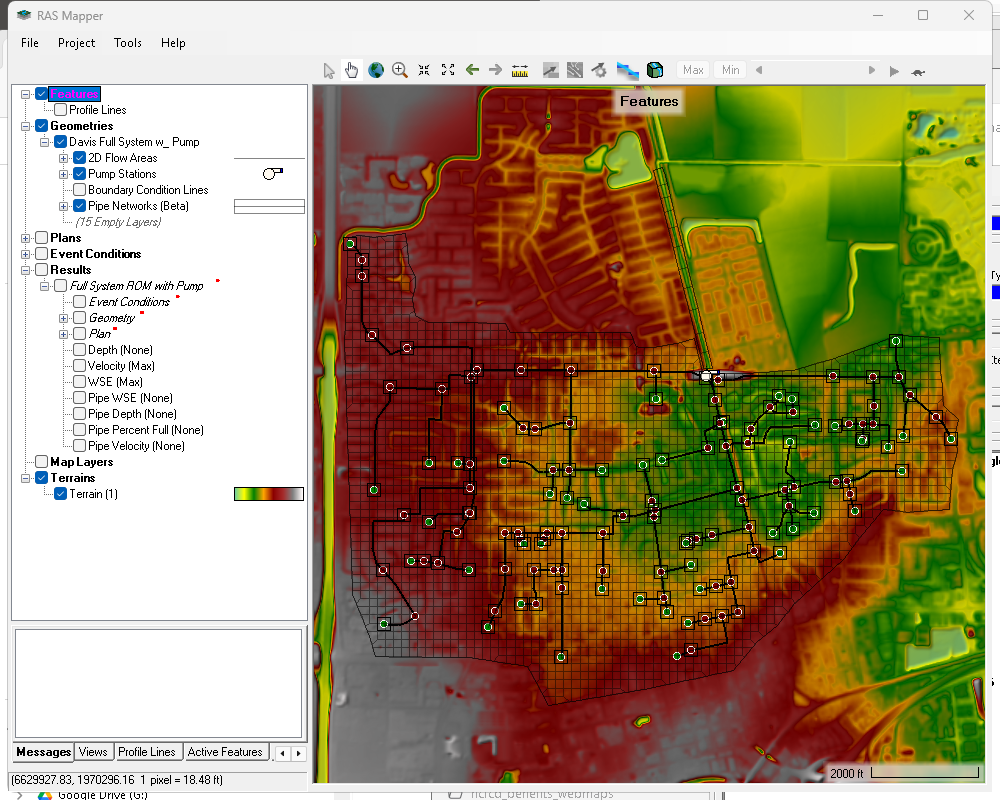

In [14]:
review_states["Davis storm system"] = create_demo_review(
    "Davis",
    title="Davis Pipes Pumps Storage and 2D Area",
    geometry_number="02",
    layer_type=[
        "RASD2FlowArea",
        "RASPipeNetworks",
        "RASPipeNodes",
        "RASPipeLinks",
        "PumpStationLayer",
        "PumpLayer",
        "RASStorageArea",
        "StructureLayer",
    ],
    terrain_name=first_terrain_name(Path(projects["Davis"])),
)

2026-04-29 09:00:46 - ras_commander.RasMap - INFO - Found 2 map layers in .rasmap


2026-04-29 09:00:46 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe via filesystem (x86)


2026-04-29 09:00:46 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 5\Ras.exe via filesystem (x86)


2026-04-29 09:00:46 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 4 at C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 4\Ras.exe via filesystem (x86)


2026-04-29 09:00:46 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.5 at C:\Program Files (x86)\HEC\HEC-RAS\6.5\Ras.exe via filesystem (x86)


...

### New Orleans Metro Pipes Pumps Breaklines and SA2D

Project: `C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\NewOrleansMetro_rasmapper_demo`

Review folder: `C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\NewOrleansMetro_rasmapper_demo\RASMapper Screenshots`

,code,passed,message
0,rasmap_exists,True,RASMapper file exists: C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\NewOrleansMetro_rasmap...
1,geometry_layers_found,True,Geometry layers were found in the .rasmap.
2,selected_geometry_layers_found,True,Selected geometry layer(s) were found.
3,selected_geometry_hdf_exists,True,Selected geometry layer HDF files exist.
4,selected_geometry_features_found,True,Selected geometry feature(s) were found.
5,selected_map_layers_found,True,Selected map layer(s) were found.
6,selected_terrain_found,True,Selected terrain layer exists: NGOMTopoBathy-PCCPSurveys


**Screenshot:** `C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\NewOrleansMetro_rasmapper_demo\RASMapper Screenshots\New_Orleans_Metro_Pipes_Pumps_Breaklines_and_SA2D.png`

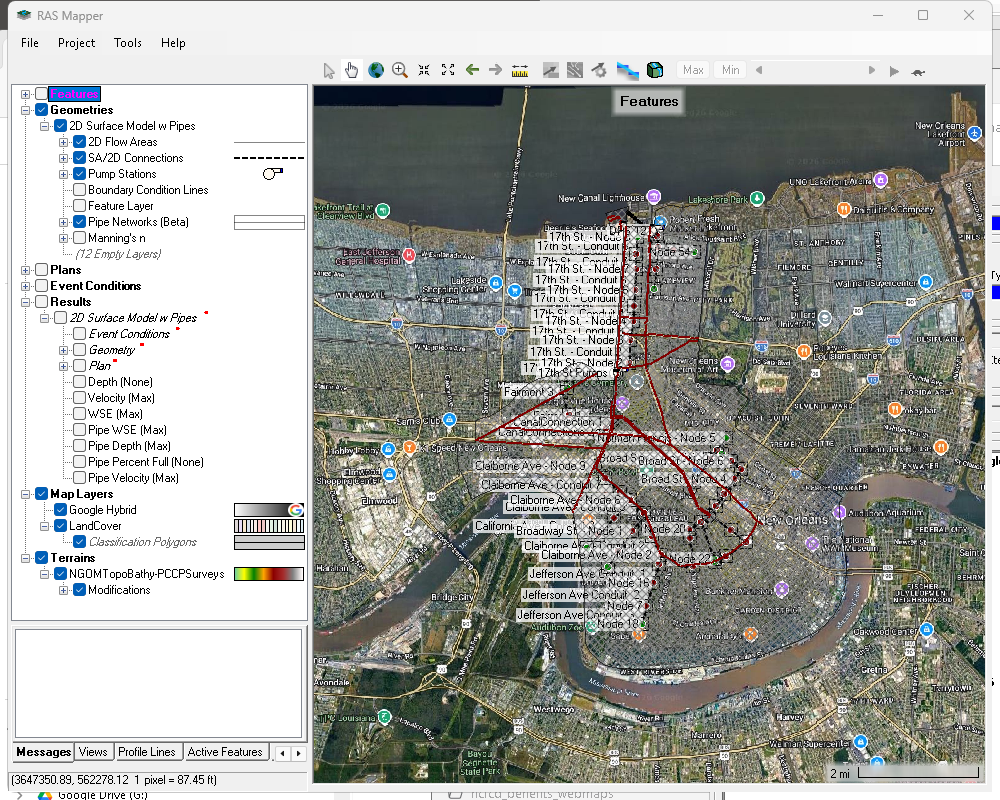

In [15]:
review_states["New Orleans metro"] = create_demo_review(
    "NewOrleansMetro",
    title="New Orleans Metro Pipes Pumps Breaklines and SA2D",
    geometry_number="02",
    layer_type=[
        "RASD2FlowArea",
        "RASBreakLines",
        "SA2DStructureLayer",
        "RASPipeNetworks",
        "RASPipeNodes",
        "RASPipeLinks",
        "PumpStationLayer",
        "PumpLayer",
    ],
    terrain_name=first_terrain_name(Path(projects["NewOrleansMetro"])),
    feature_index=0,
    map_layer_category=maybe_map_category(Path(projects["NewOrleansMetro"]), ["land_classification", "basemap"]),
)

## Result Layer State

Many fresh example projects do not have populated RASMapper result layers until results are generated or maps are stored. The functions still provide a uniform tree API: list what exists, hide all results for clean geometry figures, or show selected result context when present.

In [16]:
result_summary = []
for name, project_path in projects.items():
    result_layers = RasMap.list_result_layers(project_path)
    result_summary.append({"project": name, "result_rows": len(result_layers)})
    if not result_layers.empty:
        RasMap.set_result_layer_visibility(project_path, checked=False)
        first_plan = result_layers["plan_name"].dropna().iloc[0]
        RasMap.set_result_layer_visibility(project_path, plan_name=first_plan, checked=True, exclusive=True)
        display(Markdown(f"### {name}: result layers"))
        compact_display(RasMap.list_result_layers(project_path), max_rows=20)

display(pd.DataFrame(result_summary))

### Davis: result layers

,layer_id,category,plan_name,plan_filename,layer_name,layer_type,checked,expanded,result_index,layer_index,depth,layer_path,filename,parent_identifiers,profile_index
0,result:0,result_plan,Full System ROM with Pump,.\DavisStormSystem.p02.hdf,Full System ROM with Pump,RASResults,True,True,0,,0,Full System ROM with Pump,.\DavisStormSystem.p02.hdf,,
1,result:0:layer:0:RASEventConditions:Event Conditions,result_layer,Full System ROM with Pump,,Event Conditions,RASEventConditions,True,None,0,0,1,Full System ROM with Pump/Event Conditions,.\DavisStormSystem.p02.hdf,,
2,result:0:layer:1:RASGeometry,result_layer,Full System ROM with Pump,,,RASGeometry,True,None,0,1,1,Full System ROM with Pump/,.\DavisStormSystem.p02.hdf,,
3,result:0:layer:1.0:RASXS,result_layer,Full System ROM with Pump,,,RASXS,True,None,0,1.0,2,Full System ROM with Pump//,,,
4,result:0:layer:1.1:VirtualGeometryFeatureLayer:Culvert Groups,result_layer,Full System ROM with Pump,,Culvert Groups,VirtualGeometryFeatureLayer,True,None,0,1.1,2,Full System ROM with Pump//Culvert Groups,,,
5,result:0:layer:1.2:VirtualGeometryFeatureLayer:Culvert Barrels,result_layer,Full System ROM with Pump,,Culvert Barrels,VirtualGeometryFeatureLayer,True,None,0,1.2,2,Full System ROM with Pump//Culvert Barrels,,Bridges/Culverts,
6,result:0:layer:1.3:VirtualGeometryFeatureLayer:Gate Groups,result_layer,Full System ROM with Pump,,Gate Groups,VirtualGeometryFeatureLayer,True,None,0,1.3,2,Full System ROM with Pump//Gate Groups,,,
7,result:0:layer:1.4:VirtualGeometryFeatureLayer:Gate Openings,result_layer,Full System ROM with Pump,,Gate Openings,VirtualGeometryFeatureLayer,True,None,0,1.4,2,Full System ROM with Pump//Gate Openings,,Inline Structures,
8,result:0:layer:1.5:VirtualGeometryFeatureLayer:Culvert Groups,result_layer,Full System ROM with Pump,,Culvert Groups,VirtualGeometryFeatureLayer,True,None,0,1.5,2,Full System ROM with Pump//Culvert Groups,,,
9,result:0:layer:1.6:VirtualGeometryFeatureLayer:Culvert Barrels,result_layer,Full System ROM with Pump,,Culvert Barrels,VirtualGeometryFeatureLayer,True,None,0,1.6,2,Full System ROM with Pump//Culvert Barrels,,Inline Structures,


### NewOrleansMetro: result layers

,layer_id,category,plan_name,plan_filename,layer_name,layer_type,checked,expanded,result_index,layer_index,depth,layer_path,filename,parent_identifiers,profile_index
0,result:0,result_plan,2D Surface Model w Pipes,.\NewOrleansMetro.p01.hdf,2D Surface Model w Pipes,RASResults,True,True,0,,0,2D Surface Model w Pipes,.\NewOrleansMetro.p01.hdf,,
1,result:0:layer:0:RASEventConditions:Event Conditions,result_layer,2D Surface Model w Pipes,,Event Conditions,RASEventConditions,True,None,0,0,1,2D Surface Model w Pipes/Event Conditions,.\NewOrleansMetro.p01.hdf,,
2,result:0:layer:1:RASGeometry,result_layer,2D Surface Model w Pipes,,,RASGeometry,True,None,0,1,1,2D Surface Model w Pipes/,.\NewOrleansMetro.p01.hdf,,
3,result:0:layer:1.0:RASXS,result_layer,2D Surface Model w Pipes,,,RASXS,True,None,0,1.0,2,2D Surface Model w Pipes//,,,
4,result:0:layer:1.1:VirtualGeometryFeatureLayer:Culvert Groups,result_layer,2D Surface Model w Pipes,,Culvert Groups,VirtualGeometryFeatureLayer,True,None,0,1.1,2,2D Surface Model w Pipes//Culvert Groups,,,
5,result:0:layer:1.2:VirtualGeometryFeatureLayer:Culvert Barrels,result_layer,2D Surface Model w Pipes,,Culvert Barrels,VirtualGeometryFeatureLayer,True,None,0,1.2,2,2D Surface Model w Pipes//Culvert Barrels,,Bridges/Culverts,
6,result:0:layer:1.3:VirtualGeometryFeatureLayer:Gate Groups,result_layer,2D Surface Model w Pipes,,Gate Groups,VirtualGeometryFeatureLayer,True,None,0,1.3,2,2D Surface Model w Pipes//Gate Groups,,,
7,result:0:layer:1.4:VirtualGeometryFeatureLayer:Gate Openings,result_layer,2D Surface Model w Pipes,,Gate Openings,VirtualGeometryFeatureLayer,True,None,0,1.4,2,2D Surface Model w Pipes//Gate Openings,,Inline Structures,
8,result:0:layer:1.5:VirtualGeometryFeatureLayer:Culvert Groups,result_layer,2D Surface Model w Pipes,,Culvert Groups,VirtualGeometryFeatureLayer,True,None,0,1.5,2,2D Surface Model w Pipes//Culvert Groups,,,
9,result:0:layer:1.6:VirtualGeometryFeatureLayer:Culvert Barrels,result_layer,2D Surface Model w Pipes,,Culvert Barrels,VirtualGeometryFeatureLayer,True,None,0,1.6,2,2D Surface Model w Pipes//Culvert Barrels,,Inline Structures,


,project,result_rows
0,Balde Eagle Creek,0
1,Muncie,0
2,BaldEagleCrkMulti2D,0
3,Davis,40
4,NewOrleansMetro,41


## Low-Level RASMapper Window Primitives

`create_spatial_review_package()` is the recommended public workflow. The lower-level functions are exposed for custom orchestration when you want to configure `.rasmap` state yourself, open standalone RASMapper, capture a visible window, and close the process by PID.

In [17]:
if RUN_LOW_LEVEL_CAPTURE and CAPTURE_SNAPSHOTS:
    project_path = Path(projects["Muncie"])
    screenshot_path = project_path / "RASMapper Screenshots" / "low_level_manual_capture.png"
    screenshot_path.parent.mkdir(exist_ok=True)

    process = RasMap.open_rasmapper(project_path, ras_version=RAS_VERSION)
    try:
        captured = RasMap.capture_rasmapper_snapshot(
            pid=process.pid,
            output_path=screenshot_path,
            delay_seconds=SNAPSHOT_DELAY_SECONDS,
            timeout_seconds=SNAPSHOT_TIMEOUT_SECONDS,
        )
        if captured:
            display(Image(filename=str(captured)))
    finally:
        RasMap.close_rasmapper(pid=process.pid)
else:
    display(Markdown("Low-level capture skipped. Set `RUN_LOW_LEVEL_CAPTURE = True` in the first cell to run it."))

Low-level capture skipped. Set `RUN_LOW_LEVEL_CAPTURE = True` in the first cell to run it.

## Review Artifacts

The screenshot folder also contains CSV and JSON artifacts that agents or engineers can review without reopening RASMapper.

In [18]:
artifact_rows = []
for label, state in review_states.items():
    artifacts = state.get("artifacts", {})
    artifact_rows.append(
        {
            "review": label,
            "passed": state.get("passed"),
            "output_dir": state.get("output_dir"),
            "snapshot": state.get("snapshot", {}).get("path"),
            "geometry_layers": artifacts.get("geometry_layers"),
            "geometry_features": artifacts.get("geometry_features"),
            "map_layers": artifacts.get("map_layers"),
            "review_state": artifacts.get("review_state"),
        }
    )

display(pd.DataFrame(artifact_rows))

,review,passed,output_dir,snapshot,geometry_layers,geometry_features,map_layers,review_state
0,Balde Eagle Creek 1D XS,True,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Balde Eagle Creek_rasmapper_demo\RASMapper Sc...,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Balde Eagle Creek_rasmapper_demo\RASMapper Sc...,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Balde Eagle Creek_rasmapper_demo\RASMapper Sc...,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Balde Eagle Creek_rasmapper_demo\RASMapper Sc...,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Balde Eagle Creek_rasmapper_demo\RASMapper Sc...,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Balde Eagle Creek_rasmapper_demo\RASMapper Sc...
1,Muncie 2D structures,True,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Muncie_rasmapper_demo\RASMapper Screenshots,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Muncie_rasmapper_demo\RASMapper Screenshots\M...,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Muncie_rasmapper_demo\RASMapper Screenshots\g...,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Muncie_rasmapper_demo\RASMapper Screenshots\g...,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Muncie_rasmapper_demo\RASMapper Screenshots\m...,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Muncie_rasmapper_demo\RASMapper Screenshots\r...
2,BaldEagleCrkMulti2D breaklines,True,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_rasmapper_demo\RASMapper ...,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_rasmapper_demo\RASMapper ...,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_rasmapper_demo\RASMapper ...,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_rasmapper_demo\RASMapper ...,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_rasmapper_demo\RASMapper ...,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\BaldEagleCrkMulti2D_rasmapper_demo\RASMapper ...
3,Davis storm system,True,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Davis_rasmapper_demo\RASMapper Screenshots,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Davis_rasmapper_demo\RASMapper Screenshots\Da...,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Davis_rasmapper_demo\RASMapper Screenshots\ge...,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Davis_rasmapper_demo\RASMapper Screenshots\ge...,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Davis_rasmapper_demo\RASMapper Screenshots\ma...,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\Davis_rasmapper_demo\RASMapper Screenshots\re...
4,New Orleans metro,True,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\NewOrleansMetro_rasmapper_demo\RASMapper Scre...,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\NewOrleansMetro_rasmapper_demo\RASMapper Scre...,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\NewOrleansMetro_rasmapper_demo\RASMapper Scre...,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\NewOrleansMetro_rasmapper_demo\RASMapper Scre...,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\NewOrleansMetro_rasmapper_demo\RASMapper Scre...,C:\GH\ras-commander\working\notebook_runs\122_rasmapper_spatial_review\NewOrleansMetro_rasmapper_demo\RASMapper Scre...
